# Part 08: BERT Encoder: Bidirectional Understanding

> **Previous context**: GPT predicts the next token with a causal mask. BERT uses a different mask so tokens can read both directions.
> **Goal for this part**: Build a small encoder-only model and understand Masked Language Modeling (MLM).

Today we are solving one concrete confusion: what is the hidden mechanism behind this part of an LLM, and how can we rebuild it with small numbers before trusting a library?

## 0. Decoder vs encoder

GPT is good at continuation because it reads left to right. BERT is good at understanding because every token can attend to both left and right context.

## 1. MLM task

Instead of predicting the next token, BERT hides some tokens and asks the model to recover them from surrounding context.

## 2. Classification head

Encoder representations can feed tasks such as classification because they summarize the whole input with bidirectional context.

## 3. Key distinction

BERT is not a text generator in the same way GPT is; it is mainly an encoder for understanding tasks.

## How to use the code cells

Run the cells in order. The code is intentionally direct and small: each cell should expose one idea, print the key observation, and let you change a number to see what moves.

## Exercises

When a cell contains a TODO placeholder, fill it yourself and use the `assert` checks as feedback. You can ask an AI for hints, step-by-step reasoning, or a direction check, but avoid asking it to complete the exercise outright.

## Summary Checklist

- BERT uses bidirectional attention.
- MLM trains the model to recover masked tokens.
- Encoder outputs are useful for understanding and classification tasks.

Next, continue through the code cells for the Training Systems part and inspect the printed observations.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

In [2]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================

# Teaching note: follow this line to see the main step.
VOCAB_SIZE = 100
D_MODEL = 16
MAX_LEN = 20
NUM_SEGMENTS = 2  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
token_embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
segment_embed = nn.Embedding(NUM_SEGMENTS, D_MODEL)
position_embed = nn.Embedding(MAX_LEN, D_MODEL)

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

sentence_A = [1, 5, 8, 3, 2]    # Teaching note: follow this line to see the main step.
sentence_B = [6, 8, 4, 2]        # Teaching note: follow this line to see the main step.
full_ids = sentence_A + sentence_B
seq_len = len(full_ids)

print("Step 1: Token IDs")
print(f"  Input: {full_ids}")
print(f"Read the values printed above and connect them to the concept in this cell.")

# Teaching note: follow this line to see the main step.
segment_ids = [0] * len(sentence_A) + [1] * len(sentence_B)
print(f"\nStep 2: Segment IDs")
print(f"  Segments: {segment_ids}")
print(f"Read the values printed above and connect them to the concept in this cell.{len(sentence_A)}Read the values printed above and connect them to the concept in this cell.{len(sentence_B)}Read the values printed above and connect them to the concept in this cell.")

# Position IDs：0, 1, 2, ..., seq_len-1
position_ids = list(range(seq_len))
print(f"\nStep 3: Position IDs")
print(f"  Positions: {position_ids}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
tokens_t = torch.tensor(full_ids)
segments_t = torch.tensor(segment_ids)
positions_t = torch.tensor(position_ids)

tok_emb = token_embed(tokens_t)    # (seq_len, D_MODEL)
seg_emb = segment_embed(segments_t)  # (seq_len, D_MODEL)
pos_emb = position_embed(positions_t)  # (seq_len, D_MODEL)

input_embeddings = tok_emb + seg_emb + pos_emb

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"  Token Embedding shape:    {tok_emb.shape}")
print(f"  Segment Embedding shape:  {seg_emb.shape}")
print(f"  Position Embedding shape: {pos_emb.shape}")
print(f"Read the values printed above and connect them to the concept in this cell.{input_embeddings.shape}")

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
idx_a = 2  # Teaching note: follow this line to see the main step.
idx_b = len(sentence_A) + 1  # Teaching note: follow this line to see the main step.

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{idx_a}Read the values printed above and connect them to the concept in this cell.")
print(f"    {input_embeddings[idx_a, :6].detach()}")
print(f"Read the values printed above and connect them to the concept in this cell.{idx_b}Read the values printed above and connect them to the concept in this cell.")
print(f"    {input_embeddings[idx_b, :6].detach()}")
print(f"Read the values printed above and connect them to the concept in this cell.{(input_embeddings[idx_a] == input_embeddings[idx_b]).all().item()}")
print(f"Read the values printed above and connect them to the concept in this cell.")

Step 1: Token IDs
  Input: [1, 5, 8, 3, 2, 6, 8, 4, 2]
Read the values printed above and connect them to the concept in this cell.
Step 2: Segment IDs
  Segments: [0, 0, 0, 0, 0, 1, 1, 1, 1]
Read the values printed above and connect them to the concept in this cell.
Step 3: Position IDs
  Positions: [0, 1, 2, 3, 4, 5, 6, 7, 8]

Read the values printed above and connect them to the concept in this cell.  Token Embedding shape:    torch.Size([9, 16])
  Segment Embedding shape:  torch.Size([9, 16])
  Position Embedding shape: torch.Size([9, 16])
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.    tensor([ 1.7462,  1.3668, -1.6681, -0.8311, -0.6420,  3.6566])
Read the values printed above and connect them to the concept in this cell.    tensor([ 1.8207, -0.1974, -1.4914,  0.9783, -1.8119,  1.2722])
Read the values 

In [3]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
seq_len = 6

# Teaching note: follow this line to see the main step.
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

# Teaching note: follow this line to see the main step.
bert_mask = torch.ones(seq_len, seq_len)

tokens = ["[CLS]", 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', "[SEP]"]

print('Read the values printed above and connect them to the concept in this cell.')
print(f"Tokens: {tokens}")
print()
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if causal_mask[i, j] == 1]
    print(f"Read the values printed above and connect them to the concept in this cell.{i} ('{tokens[i]}Read the values printed above and connect them to the concept in this cell.{visible}")

print(f"Read the values printed above and connect them to the concept in this cell.")
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if bert_mask[i, j] == 1]
    print(f"Read the values printed above and connect them to the concept in this cell.{i} ('{tokens[i]}Read the values printed above and connect them to the concept in this cell.{visible}")

print(f"\nKey difference:")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed

In [4]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
class MiniBERTEncoder(nn.Module):
    'Read the values printed above and connect them to the concept in this cell.'
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # Teaching note: follow this line to see the main step.
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_O(out)

class MiniBERTBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attention = MiniBERTEncoder(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class MiniBERT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, max_len=64):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        # Teaching note: follow this line to see the main step.
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([
            MiniBERTBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def encode(self, x):
        'Read the values printed above and connect them to the concept in this cell.'
        B, S = x.shape
        positions = torch.arange(S, device=x.device).unsqueeze(0)
        x_emb = self.token_embedding(x) + self.position_embedding(positions)
        for block in self.blocks:
            x_emb = block(x_emb)
        x_emb = self.norm_final(x_emb)
        return x_emb

    def forward(self, x):
        x_emb = self.encode(x)
        return self.lm_head(x_emb)

print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.

In [5]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
VOCAB_SIZE = 50
MASK_ID = 3  # Teaching note: follow this line to see the main step.

torch.manual_seed(42)
model = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Teaching note: follow this line to see the main step.
sentences = [
    [5, 8, 10, 6, 9, 4],   # Teaching note: follow this line to see the main step.
    [5, 12, 13, 14, 4],    # Teaching note: follow this line to see the main step.
    [7, 8, 11, 6, 15, 4],  # Teaching note: follow this line to see the main step.
    [5, 16, 17, 18, 4],    # Teaching note: follow this line to see the main step.
    [7, 16, 19, 20, 4],    # Teaching note: follow this line to see the main step.
    [5, 21, 22, 9, 23, 4], # Teaching note: follow this line to see the main step.
]

# Teaching note: follow this line to see the main step.
def create_mlm_batch(sentences, mask_prob=0.15):
    'Read the values printed above and connect them to the concept in this cell.'
    # Padding
    max_len = max(len(s) for s in sentences)
    batch_size = len(sentences)
    input_ids = torch.zeros(batch_size, max_len, dtype=torch.long)
    labels = torch.full((batch_size, max_len), -100, dtype=torch.long)  # -100 = ignore

    for i, sent in enumerate(sentences):
        input_ids[i, :len(sent)] = torch.tensor(sent)

        # Teaching note: follow this line to see the main step.
        maskable = list(range(1, len(sent) - 1))
        num_mask = max(1, int(len(maskable) * mask_prob))
        mask_positions = torch.randperm(len(maskable))[:num_mask]

        for pos_idx in mask_positions:
            pos = maskable[pos_idx]
            labels[i, pos] = sent[pos]  # Teaching note: follow this line to see the main step.
            rand = torch.rand(1).item()
            if rand < 0.8:
                input_ids[i, pos] = MASK_ID  # Teaching note: follow this line to see the main step.
            elif rand < 0.9:
                input_ids[i, pos] = torch.randint(5, 25, (1,)).item()  # Teaching note: follow this line to see the main step.
            # Teaching note: follow this line to see the main step.

    return input_ids, labels

# Teaching note: follow this line to see the main step.
input_ids, labels = create_mlm_batch(sentences)

print('Read the values printed above and connect them to the concept in this cell.')
print(f"MASK_ID = {MASK_ID}")
print()
for i in range(len(sentences)):
    print(f"Read the values printed above and connect them to the concept in this cell.{i+1}:")
    print(f"Read the values printed above and connect them to the concept in this cell.{sentences[i]}")
    print(f"  Input: {input_ids[i].tolist()}")
    label_row = labels[i].tolist()
    print(f"  labels: {[('MASK→'+str(l) if l != -100 else 'ignore') for l in label_row]}")
    print()

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print('"=== training MiniBERT (MLM) ==="')
NUM_EPOCHS = 200
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    logits = model(input_ids)  # (B, S, V)
    loss = F.cross_entropy(
        logits.view(-1, VOCAB_SIZE),
        labels.view(-1),
        ignore_index=-100  # Teaching note: follow this line to see the main step.
    )
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 20 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"Loss{losses[0]:.4f}Loss{losses[-1]:.4f}")

Read the values printed above and connect them to the concept in this cell.MASK_ID = 3

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [5, 8, 3, 6, 9, 4]  labels: ['ignore', 'ignore', 'MASK→10', 'ignore', 'ignore', 'ignore']

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [5, 3, 13, 14, 4, 0]  labels: ['ignore', 'MASK→12', 'ignore', 'ignore', 'ignore', 'ignore']

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [7, 8, 11, 3, 15, 4]  labels: ['ignore', 'ignore', 'ignore', 'MASK→6', 'ignore', 'ignore']

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [5, 16, 

Epoch 120 | Loss: 0.0177
Epoch 140 | Loss: 0.0142
Epoch 160 | Loss: 0.0116
Epoch 180 | Loss: 0.0097
Epoch 199 | Loss: 0.0083

Loss

Read the values printed above and connect them to the concept in this cell.Input: [5, 3, 10, 6, 3, 4]Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

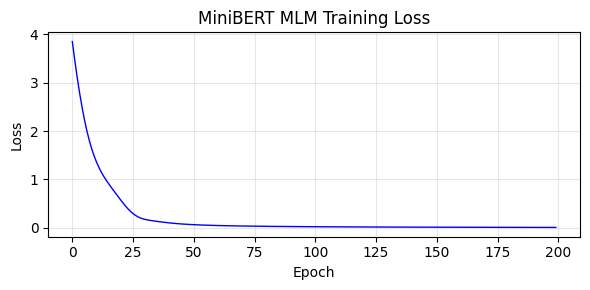

In [6]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
test_sentence = torch.tensor([[5, MASK_ID, 10, 6, MASK_ID, 4]])  # Teaching note: follow this line to see the main step.

model.eval()
with torch.no_grad():
    logits = model(test_sentence)
    predictions = logits.argmax(dim=-1)

print('Result:')
print(f"Input:  {test_sentence.tolist()[0]}")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{predictions.tolist()[0]}")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{predictions[0, 1].item()}Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{predictions[0, 4].item()}Read the values printed above and connect them to the concept in this cell.")

# Visualize loss
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MiniBERT MLM Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
class MiniBERTForClassification(nn.Module):
    'Read the values printed above and connect them to the concept in this cell.'
    def __init__(self, bert, num_classes):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(bert.d_model, num_classes)

    def forward(self, x):
        hidden = self.bert.encode(x)  # (B, S, D)
        cls_output = hidden[:, 0, :]  # Teaching note: follow this line to see the main step.
        return self.classifier(cls_output)  # → (B, num_classes)

# Teaching note: follow this line to see the main step.
VOCAB_SIZE = 50
bert_base = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
clf_model = MiniBERTForClassification(bert_base, num_classes=2)  # Teaching note: follow this line to see the main step.

test_input = torch.randint(0, VOCAB_SIZE, (1, 10))
output = clf_model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}  ← (batch=1, classes=2)")
print(f"Output logits: {output.tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")

Input shape: torch.Size([1, 10])Output shape: torch.Size([1, 2]) ← (batch=1, classes=2)Output logits: [[-0.058426402509212494, 0.5479098558425903]]
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [8]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
try:
    from transformers import AutoTokenizer, AutoModel

    print('Read the values printed above and connect them to the concept in this cell.')
    tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
    model = AutoModel.from_pretrained("bert-base-chinese")

    print(f"Read the values printed above and connect them to the concept in this cell.{sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
    print(f"Vocabulary size: {len(tokenizer)}")
    print()

    # Teaching note: follow this line to see the main step.
    sentences = [
        'Read the values printed above and connect them to the concept in this cell.',
        'Read the values printed above and connect them to the concept in this cell.',
    ]

    inputs = tokenizer(sentences, padding=True, return_tensors="pt")
    print(f"Input IDs shape: {inputs['input_ids'].shape}")
    print(f"Attention mask: {inputs['attention_mask']}")
    print()

    # Teaching note: follow this line to see the main step.
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    print(f"Output last_hidden_state shape: {outputs.last_hidden_state.shape}")
    print(f"  → (batch, seq_len, hidden_dim=768)")
    print()

    # Teaching note: follow this line to see the main step.
    last_layer_attn = outputs.attentions[-1]  # (batch, num_heads, seq_len, seq_len)
    print(f"Read the values printed above and connect them to the concept in this cell.{last_layer_attn.shape}")
    print(f"  → (batch, 12 heads, seq_len, seq_len)")
    print()

    # Teaching note: follow this line to see the main step.
    tokens1 = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    print(f"Read the values printed above and connect them to the concept in this cell.{tokens1}")
    print(f"Read the values printed above and connect them to the concept in this cell.")
    for i, tok in enumerate(tokens1):
        attn_weights = last_layer_attn[0, 0, i]  # Teaching note: follow this line to see the main step.
        top2 = attn_weights.topk(2)
        print(f"  '{tok}Read the values printed above and connect them to the concept in this cell.", end="")
        for j, (idx, w) in enumerate(zip(top2.indices, top2.values)):
            print(f"'{tokens1[idx]}'({w:.2f})", end="  ")
        print()

except ImportError:
    print('Read the values printed above and connect them to the concept in this cell.')
except Exception as e:
    print(f"Read the values printed above and connect them to the concept in this cell.{e}")
    print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.